In [1]:
%pip install git+https://github.com/alemartinello/dstapi

  Cloning https://github.com/alemartinello/dstapi to /private/var/folders/yb/25kkh4j95rn46zgwrp2zzjyw0000gn/T/pip-req-build-c13om52t
  Running command git clone --filter=blob:none --quiet https://github.com/alemartinello/dstapi /private/var/folders/yb/25kkh4j95rn46zgwrp2zzjyw0000gn/T/pip-req-build-c13om52t
  Resolved https://github.com/alemartinello/dstapi to commit d9eeb5a82cbc70b7d63b2ff44d92632fd77123a4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


In [2]:
#importing pandas, matplotlib and numpy
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#importing API
from dstapi import DstApi

# **1.1 The Gini Coefficient and The Top 10 Percent Share**


In [3]:
IFOR41 = DstApi('IFOR41') 

In [4]:
#Building the query parameters for IFOR41 and setting variables
params41 = IFOR41._define_base_params(language='en')
def set_var(params, code, values):
    for v in params['variables']:
        if v['code'] == code:
            v['values'] = values
    return params

params41 = set_var(params41, 'ULLIG', ['70'])
params41 = set_var(params41, 'KOMMUNEDK', ['000'])
params41 = set_var(params41, 'TID', ['*'])

# Download the data and keep only the columns we need, rename them and convert the data types
gini = IFOR41.get_data(params=params41)
gini = gini.rename(columns={'TID': 'year', 'INDHOLD': 'gini'})[['year', 'gini']]
gini['year'] = gini['year'].astype(int)
gini['gini'] = pd.to_numeric(gini['gini'], errors='coerce')
gini = gini.sort_values('year').reset_index(drop=True)                                                   

In [5]:
IFOR32 = DstApi('IFOR32')

In [6]:
params32 = IFOR32._define_base_params(language='en')
params32 = set_var(params32, 'DECILGEN', ['*'])
params32 = set_var(params32, 'KOMMUNEDK', ['000'])
params32 = set_var(params32, 'TID', ['*'])

decile = IFOR32.get_data(params=params32)
decile = decile.rename(columns={'TID': 'year', 'INDHOLD': 'avg_income'})
decile['year'] = decile['year'].astype(int)

# Sum the average income of the richest decile (10th)
total_by_year = decile.groupby('year')['avg_income'].sum().rename('total_avg_income')
# Isolate the average income of the richest decile (10th)
top10 = decile.loc[decile['DECILGEN'] == 'Tenth decil', ['year', 'avg_income']].rename(columns={'avg_income': 'top10_avg_income'})

# Combine the two DataFrames and calculate the share of the top 10% income
top10 = top10.merge(total_by_year, on='year', validate='1:1')
top10['top10_share'] = 100*top10['top10_avg_income'] / top10['total_avg_income']
top10 = top10[['year', 'top10_share']]

In [7]:
# validate that the two DataFrames have the same years and merge them
df = pd.merge(gini, top10, on='year', validate='1:1')

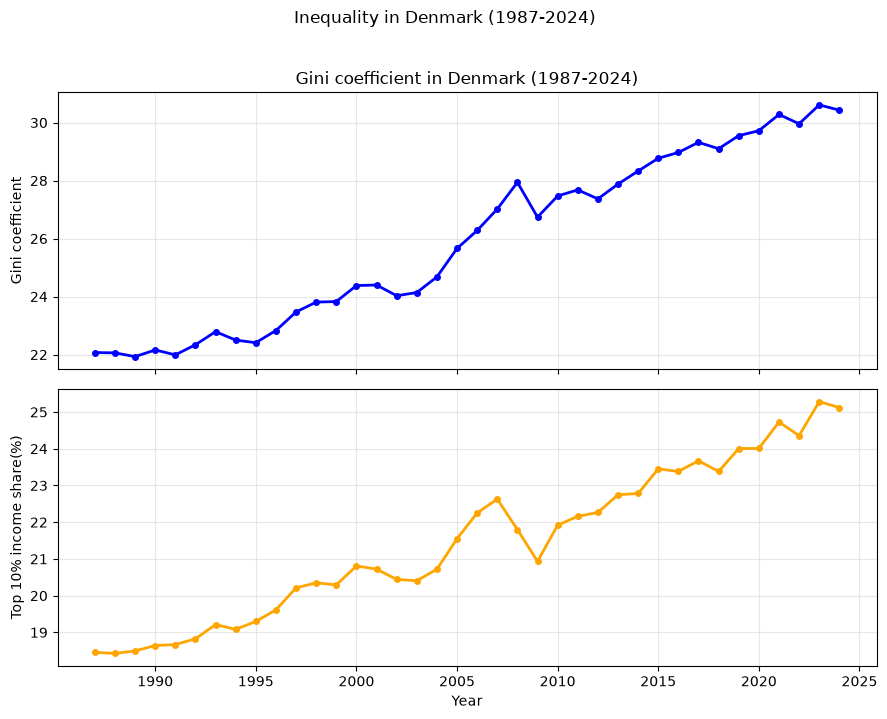

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

#Top panel: Gini coefficient over time
axes[0].plot(df['year'], df['gini'], color='blue', linewidth=2, marker='o', markersize=4)
axes[0].set_ylabel('Gini coefficient')
axes[0].set_title('Gini coefficient in Denmark (1987-2024)')
axes[0].grid(True, alpha=0.3)

#Bottom panel: Top 10% income share over time
axes[1].plot(df['year'], df['top10_share'], color='orange', linewidth=2, marker='o', markersize=4)
axes[1].set_ylabel('Top 10% income share(%)')
axes[1].set_xlabel('Year')
axes[1].xaxis.set_major_locator(plt.MultipleLocator(5))
axes[1].grid(True, alpha=0.3)

fig.suptitle('Inequality in Denmark (1987-2024)', y=1.02)
fig.tight_layout()
plt.show()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Inequality in Denmark (1987-2024)', y=1.02)
fig.tight_layout()
plt.show()

In [9]:
# Correlation between Gini coefficient and top 10% income share
corr = df['gini'].corr(df['top10_share'])
print(f"Correlation between Gini coefficient and top 10% income share: {corr:.3f}")

Correlation between Gini coefficient and top 10% income share: 0.982


# answer to the question: Describe how inequality in Denmark has developed since 1987. Do the two measures tell the same story?

Income inequality in Denmark has risen fairly steadily since 1987. The gini coefficient increased from about 22 in 1987 to around 30 in 2024, and the income share of the richest 10% rose from roughly 18.5% to 25% over the same period. Both measures a noticable dip around 2008-2009, likely due to the financial crisis, before resuming their upward trend. 

The two measures tell largely the same story: both show a clear, sustained increase in inequality over the period, and they move together closely, with a correlation of 0.982. This makes sense, since both capture aspects of the same underlying income distribution, where the gini coefficient summarizes inequality across the whole distribution, while the top 10% share focuses specifically on the top of it.

# **1.2 Prediction**

In [10]:
from scipy.optimize import minimize

#convert the years to "years since 1987"
t = (df['year'] - 1987).values
y = df['gini'].values

In [11]:
def sse(beta, t, y): 
    # Sum of squared errors for a polynomial regression model
    p = len(beta)-1
    y_pred = sum(beta[k]*t**k for k in range(p+1))
    return np.sum((y - y_pred)**2)

In [12]:
# Linear trend: beta = (beta_0, beta_1)
beta_linear0 = [y.mean(), 0]  # initial guess for beta_0 and beta_1
res_linear = minimize(sse, beta_linear0, args=(t, y))
beta_linear = res_linear.x
print('linear trend coefficients:', beta_linear)

# Qudratic trend: beta = (beta_0, beta_1, beta_2)
beta_quadratic0 = [y.mean(), 0, 0] 
res_quadratic = minimize(sse, beta_quadratic0, args=(t, y))
beta_quadratic = res_quadratic.x

linear trend coefficients: [21.04275388  0.26354958]


In [13]:
# np.polyfit returns coefficients in descending order, so we need to reverse them to match our sse function
poly_linear = np.polyfit(t, y, 1)[::-1]
poly_quadratic = np.polyfit(t, y, 2)[::-1]

In [14]:
def predict(beta, n):
    # Predicted gini coefficient for n years since 1987
    P = len(beta)-1
    return sum(beta[k]*n**k for k in range(P+1))

years_predict = [2030, 2040]

for yr in years_predict:
    n = yr - 1987
    pred_linear = predict(beta_linear, n)
    pred_quadratic = predict(beta_quadratic, n)

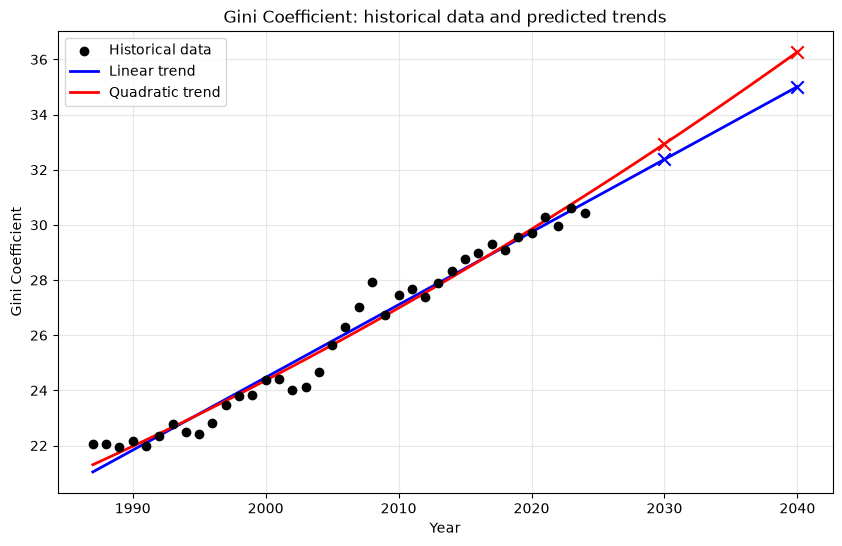

In [15]:
# Build a smooth range from 1987 to 2040 to draw fitted trend lines
fig, ax = plt.subplots(figsize=(10, 6))
t_plot = np.arange(0, (2040-1987)+1)
years_plot = t_plot + 1987

gini_linear_plot = predict(beta_linear, t_plot)
gini_quadratic_plot = predict(beta_quadratic, t_plot)

# Historical gini coefficient data
ax.scatter(df['year'], df['gini'], color='black', label='Historical data', zorder=5)

# Fitted trends, extrapolated out to 2040
ax.plot(years_plot, gini_linear_plot, color='blue', linewidth=2, label='Linear trend')
ax.plot(years_plot, gini_quadratic_plot, color='red', linewidth=2, label='Quadratic trend')

# Highlight the predictions for 2030 and 2040
for yr in years_predict:
    n = yr - 1987
    ax.scatter(yr, predict(beta_linear, n), color='blue', marker='x', s=80, zorder=4)
    ax.scatter(yr, predict(beta_quadratic, n), color='red', marker='x', s=80, zorder=4)

ax.set_xlabel('Year')
ax.set_ylabel('Gini Coefficient')
ax.set_title('Gini Coefficient: historical data and predicted trends')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


In [16]:
print(f'Linear coefficients (scipy):', beta_linear)
print(f'Quadratic coefficients (scipy):', beta_quadratic)

Linear coefficients (scipy): [21.04275388  0.26354958]
Quadratic coefficients (scipy): [2.13041543e+01 2.19983176e-01 1.17746752e-03]


In [17]:
for yr in years_predict:
    n = yr - 1987
    print(f'{yr}: linear = {predict(beta_linear, n):.2f}, quadratic = {predict(beta_quadratic, n):.2f}')

2030: linear = 32.38, quadratic = 32.94
2040: linear = 35.01, quadratic = 36.27


# Answer to the question: How well do the two specifications fit the historical data? How much do their pre-dictions differ? Would you trust either of them, and why?

Both trends fit the historical data well and are nearly indistinguishable over 1987-2024. Their predictions diverge more the further out we go, for 2030 thy are close (32.38 vs 32.94), but by 2040 the gap widens (35.01 vs 36.27), since even the small positive qudratic term compounds quickly outside the sample. 

I wouldn't trust either prediction much, especially for 2040. Both simply extrapolate the historical trend, assumin today's drivers of inequality continue unchanged, and increasingly shaky assumption over a longer horizon, and on the recent flattening in the data (2020-2024) already casts doubt on. 

# **1.3 Municipalities**

In [18]:
# Downloading municipal level data for Gini coefficient
IFOR41 = DstApi('IFOR41')

params41 = IFOR41._define_base_params(language='en') # Define the base parameters for the API request

df_gini = IFOR41.get_data(params=params41) # Download the data from the API

df_gini = df_gini[df_gini["ULLIG"] == "Gini coefficient"].reset_index(drop=True) # Remove rows that are not Gini coefficient

df_gini = df_gini.sort_values(by=['KOMMUNEDK', 'TID']).reset_index(drop=True) # Sort the data by year and municipality code

df_gini = df_gini[df_gini['KOMMUNEDK'] != 'All Denmark'].reset_index(drop=True) # Remove rows that are for all Denmark, we only want municipal level data

display(df_gini.head())
display(df_gini.tail())
display(df_gini.shape)

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,Aabenraa,1987,21.33
1,Gini coefficient,Aabenraa,1988,21.51
2,Gini coefficient,Aabenraa,1989,20.74
3,Gini coefficient,Aabenraa,1990,20.83
4,Gini coefficient,Aabenraa,1991,20.86


,ULLIG,KOMMUNEDK,TID,INDHOLD
3719,Gini coefficient,Ærø,2020,25.61
3720,Gini coefficient,Ærø,2021,26.63
3721,Gini coefficient,Ærø,2022,27.02
3722,Gini coefficient,Ærø,2023,27.67
3723,Gini coefficient,Ærø,2024,26.98


(3724, 4)

In [19]:
# Downloading municipal level data for top 10% income share
IFOR32 = DstApi('IFOR32')

params32 = IFOR32._define_base_params(language='en') # Define the base parameters for the API request

df_top10 = IFOR32.get_data(params=params32) # Download the data from the API

df_top10 = df_top10[df_top10["DECILGEN"] == "Tenth decil"].reset_index(drop=True) # Remove rows that are not for the top 10% income share

df_top10 = df_top10.sort_values(by=['TID', 'KOMMUNEDK']).reset_index(drop=True) # Sort the data by year and municipality code

df_top10 = df_top10[df_top10['KOMMUNEDK'] != 'All Denmark'].reset_index(drop=True) # Remove rows that are for all Denmark, we only want municipal level data

display(df_top10.head())
display(df_top10.tail())
display(df_top10.shape)


,DECILGEN,KOMMUNEDK,TID,INDHOLD
0,Tenth decil,Aabenraa,1987,160791
1,Tenth decil,Aalborg,1987,156630
2,Tenth decil,Aarhus,1987,166182
3,Tenth decil,Albertslund,1987,162156
4,Tenth decil,Allerød,1987,205967


,DECILGEN,KOMMUNEDK,TID,INDHOLD
3719,Tenth decil,Vejle,2024,803937
3720,Tenth decil,Vesthimmerlands,2024,679892
3721,Tenth decil,Viborg,2024,707836
3722,Tenth decil,Vordingborg,2024,643769
3723,Tenth decil,Ærø,2024,598614


(3724, 4)

In [20]:
merge_df = pd.merge(df_gini, df_top10, on=['KOMMUNEDK', 'TID'], suffixes=('_gini', '_top10')) # Merging the two DataFrames on year and municipality code, adding suffixes to distinguish between the two datasets

merge_df = merge_df.rename(columns={'TID': 'year', 'INDHOLD_gini': 'gini', 'INDHOLD_top10': 'top10_share'}) # Renaming the columns to be more descriptive

merge_df = merge_df.drop(columns=['DECILGEN', 'ULLIG']) # Dropping the columns that are no longer needed

# Correlation between Gini coefficient and top 10% income share at the municipal level
corr = (
    merge_df.groupby('KOMMUNEDK')
      .apply(lambda x: x['gini'].corr(x['top10_share']))
      .rename("correlation")
)

merge_df = merge_df.merge(corr, on='KOMMUNEDK') # Adding the correlation values to the merged DataFrame

display(merge_df.head())

df_corr = merge_df[['KOMMUNEDK', 'correlation']].drop_duplicates().reset_index(drop=True) # Creating a new DataFrame with the correlation values for each municipality

df_corr = df_corr.sort_values(by='correlation', ascending=False).reset_index(drop=True) # Sorting the DataFrame by correlation values in descending order

print(f"Municipal level correlation between Gini coefficient and top 10% income share:\n{df_corr}")
print(f"Mean correlation: {df_corr['correlation'].mean():.3f}, median correlation: {df_corr['correlation'].median():.3f}")

,KOMMUNEDK,year,gini,top10_share,correlation
0,Aabenraa,1987,21.33,160791,0.949947
1,Aabenraa,1988,21.51,169217,0.949947
2,Aabenraa,1989,20.74,178127,0.949947
3,Aabenraa,1990,20.83,186215,0.949947
4,Aabenraa,1991,20.86,200033,0.949947


Municipal level correlation between Gini coefficient and top 10% income share:
          KOMMUNEDK  correlation
0           Rødovre     0.986106
1              Køge     0.985781
2        Vallensbæk     0.985339
3        Fredericia     0.984886
4    Lyngby-Taarbæk     0.983701
..              ...          ...
93  Vesthimmerlands     0.798686
94        Silkeborg     0.777709
95           Rebild     0.762885
96      Brønderslev     0.746560
97             Læsø     0.629879

[98 rows x 2 columns]
Mean correlation: 0.921, median correlation: 0.947


**Q: 1.3-1: Is it similar to the correlation over time you found above?**

The correlation found in Q 1.1 was 0.982. The correlations measured on a municipal level by mean and median with the respective values of 0.921 and 0.947, are significantly lower. The reason is that the correlation on a municipality level doesn't take municipality population into consideration. Meaning that the smaller municipalities measured by population skews the results.

In [21]:
# Using Gini Coefficient data to find the 10 most equal and 10 most unequal municipalities in Denmark
df_latest_gini = ( # Find the latest year for each municipality and keep only those rows
    df_gini.loc[df_gini.groupby("KOMMUNEDK")["TID"].idxmax(),
           ["KOMMUNEDK", "INDHOLD"]]
      .rename(columns={"INDHOLD": "gini"})
      .reset_index(drop=True)
)

df_latest_gini = df_latest_gini.sort_values(by="gini", ascending=False).reset_index(drop=True) # Sort the DataFrame by Gini coefficient in descending order

display(df_latest_gini.head(10)) # Display the 10 most equal municipalities
display(df_latest_gini.tail(10)) # Display the 10 most unequal municipalities

,KOMMUNEDK,gini
0,Gentofte,49.04
1,Rudersdal,47.31
2,Vejen,46.32
3,Hørsholm,40.07
4,Lyngby-Taarbæk,39.28
5,Frederiksberg,36.54
6,Copenhagen,34.97
7,Aarhus,33.43
8,Fredensborg,32.76
9,Helsingør,30.55


,KOMMUNEDK,gini
88,Odder,24.70
89,Albertslund,24.66
90,Hedensted,24.58
91,Assens,24.46
92,Favrskov,24.41
93,Halsnæs,24.41
94,Faxe,24.09
95,Bornholm,24.03
96,Egedal,23.85
97,Faaborg-Midtfyn,23.77


**Q: 1.3-2: Describe the pattern**

The higher Gini, means the higher unequality within the municipality. The most unequal municipalities are also the richest measured by income. The reverse pattern is true for the most equal municipalities.

In [22]:
df_gini["INDHOLD"] = pd.to_numeric(df_gini["INDHOLD"], errors="coerce") # Convert the Gini coefficient values to numeric, coercing errors to NaN

df_gini = df_gini.sort_values(["KOMMUNEDK", "TID"]) # Sort the DataFrame by municipality code and year

first = df_gini.groupby("KOMMUNEDK")["INDHOLD"].transform("first") # Get the first Gini coefficient value for each municipality

# Calculate the percentage change in Gini coefficient for each municipality compared to the first year of data
df_gini["change"] = (
    (df_gini["INDHOLD"] / first - 1) * 100
).round(2)

df_gini = df_gini.sort_values(["change", "KOMMUNEDK", "TID"], ascending=[False, True, True]).reset_index(drop=True) # Sort the DataFrame by change in Gini coefficient in descending order

df_gini = df_gini.dropna(subset=["change"]) # Drop rows with NaN values in the change column

df_gini = df_gini[df_gini["TID"] == df_gini.groupby("KOMMUNEDK")["TID"].transform("max")] # Keep only the rows for the latest year for each municipality

display(df_gini.head())
display(df_gini.tail())

,ULLIG,KOMMUNEDK,TID,INDHOLD,change
2,Gini coefficient,Vejen,2024,46.32,118.49
4,Gini coefficient,Vallensbæk,2024,26.70,67.92
7,Gini coefficient,Rudersdal,2024,47.31,62.86
16,Gini coefficient,Gentofte,2024,49.04,57.68
20,Gini coefficient,Lyngby-Taarbæk,2024,39.28,57.31


,ULLIG,KOMMUNEDK,TID,INDHOLD,change
1883,Gini coefficient,Bornholm,2024,24.03,12.76
1984,Gini coefficient,Læsø,2024,25.41,11.40
1987,Gini coefficient,Faxe,2024,24.09,11.32
2135,Gini coefficient,Ærø,2024,26.98,9.54
2739,Gini coefficient,Fanø,2024,26.34,2.61


**Q: 1.3-3: Find the municipalities with the largest and the smallest change in the Gini coefficient. Illustrate and comment.**

The municipality with the biggest Gini pct. change in from 1987 to 2024 is Vejen. Other than Vejen the biggest Gini change is generally in the Copenhagen area. The lowest pct. change in Gini is Læsø, probably skewed by the small sample size.

# **1.4 Extension**

In this section we will investigate the change in the marked value of the average danish house/apartment accros municipalities and if this is a explaination of why the inequality has risen. This will be done with the help of data from Statistics of Denmarks' EJDFOE1 table. 

In [23]:
housing = DstApi('EJDFOE1') # Preparing to download municipal level data for housing market value

params_housing = housing._define_base_params(language='en') # Define the base parameters for the API request

df_housing = housing.get_data(params=params_housing) # Download the data from the API

df_housing = df_housing[df_housing["VAERDI"] == "Market value"].reset_index(drop=True) # Remove rows that are not for market value

df_housing = df_housing[df_housing["EJENTYP"] == "TOTAL, REAL ESTATE"].reset_index(drop=True) # Remove rows that are not for total real estate

df_housing = df_housing[df_housing["ENHED"] == "Average (DKK)"].reset_index(drop=True) # Remove rows that are not for average market value

df_housing = df_housing.drop(columns=["VAERDI", "EJENTYP", "ENHED"]) # Drop the columns that are no longer needed

# Calculate the total pct. change in average housing price for each municipality
df_housing = df_housing.sort_values(["BOPKOM", "TID"])

df_housing_copy = df_housing.copy()

first = df_housing_copy.groupby("BOPKOM")["INDHOLD"].transform("first") # Get the first average housing price value for each municipality

# Calculate the percentage change in average housing price for each municipality compared to the first year of data
df_housing["change_pct"] = (
    (df_housing["INDHOLD"] / first - 1) * 100
).round(2)

# Keep only the rows for the latest year for each municipality
results = (
    df_housing[df_housing["TID"] == 2025]
    .sort_values("change_pct", ascending=False)
)

df_gini = df_gini.sort_values(["change", "KOMMUNEDK", "TID"], ascending=[False, True, True]).reset_index(drop=True) # Sort the DataFrame by change in Gini coefficient in descending order

display(results.head(10)) # Display the 10 municipalities with the largest increase in average housing price
display(results.tail(10)) # Display the 10 municipalities with the largest decrease in average housing price
display(df_gini.head(10)) # Display the 10 municipalities with the largest increase in Gini coefficient
display(df_gini.tail(10)) # Display the 10 municipalities with the largest decrease in Gini coefficient

,BOPKOM,TID,INDHOLD,change_pct
2009,Frederiksberg,2025,5290050,215.49
2008,Copenhagen,2025,3766520,209.56
2023,Gentofte,2025,8672616,209.54
2074,Rødovre,2025,4845816,181.21
2024,Gladsaxe,2025,5028641,176.99
2030,Lyngby-Taarbæk,2025,6304895,176.86
2028,Hvidovre,2025,4350203,168.89
2076,Tårnby,2025,4127181,166.30
2084,Rudersdal,2025,7285317,161.02
2006,Region Hovedstaden,2025,4241327,158.78


,BOPKOM,TID,INDHOLD,change_pct
2207,Vejen,2025,1612506,39.51
2093,Guldborgsund,2025,1615662,39.30
2200,Haderslev,2025,1688290,38.55
2203,Tønder,2025,1474943,38.52
1795,Morsø,2025,1445168,38.32
1775,Struer,2025,1385300,32.69
1796,Skive,2025,1349580,31.31
1774,Lemvig,2025,1324205,30.47
2091,Lolland,2025,1333147,29.17
1808,Brønderslev,2025,1592060,27.48


,ULLIG,KOMMUNEDK,TID,INDHOLD,change
0,Gini coefficient,Vejen,2024,46.32,118.49
1,Gini coefficient,Vallensbæk,2024,26.70,67.92
2,Gini coefficient,Rudersdal,2024,47.31,62.86
3,Gini coefficient,Gentofte,2024,49.04,57.68
4,Gini coefficient,Lyngby-Taarbæk,2024,39.28,57.31
5,Gini coefficient,Fredensborg,2024,32.76,54.75
6,Gini coefficient,Copenhagen,2024,34.97,51.71
7,Gini coefficient,Aarhus,2024,33.43,51.27
8,Gini coefficient,Ballerup,2024,26.72,46.89
9,Gini coefficient,Rødovre,2024,26.33,46.85


,ULLIG,KOMMUNEDK,TID,INDHOLD,change
88,Gini coefficient,Rebild,2024,25.87,17.48
89,Gini coefficient,Mariagerfjord,2024,25.98,16.45
90,Gini coefficient,Stevns,2024,24.77,16.02
91,Gini coefficient,Faaborg-Midtfyn,2024,23.77,13.84
92,Gini coefficient,Sorø,2024,25.16,13.13
93,Gini coefficient,Bornholm,2024,24.03,12.76
94,Gini coefficient,Læsø,2024,25.41,11.40
95,Gini coefficient,Faxe,2024,24.09,11.32
96,Gini coefficient,Ærø,2024,26.98,9.54
97,Gini coefficient,Fanø,2024,26.34,2.61


Correlation = 0.474


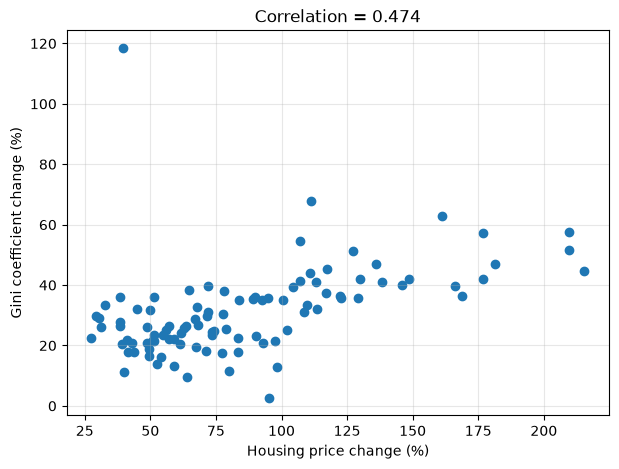

In [24]:
# Housing (already one row per municipality in 2025)
housing = results[["BOPKOM", "change_pct"]]

# Keep only the last year (2024) for each municipality
gini = (
    df_gini.sort_values(["KOMMUNEDK", "TID"])
           .groupby("KOMMUNEDK")
           .tail(1)[["KOMMUNEDK", "change"]]
)

# Merge
merged = housing.merge(
    gini,
    left_on="BOPKOM",
    right_on="KOMMUNEDK",
    how="inner"
)

# Correlation
corr = merged["change_pct"].corr(merged["change"])

print(f"Correlation = {corr:.3f}")

import matplotlib.pyplot as plt

# Plotting the correlation between housing price change and Gini coefficient change
plt.figure(figsize=(7,5))
plt.scatter(merged["change_pct"], merged["change"])
plt.xlabel("Housing price change (%)")
plt.ylabel("Gini coefficient change (%)")
plt.title(f"Correlation = {corr:.3f}")
plt.grid(alpha=0.3)
plt.show()

**Conclusion of 1.4:**

The change in Gini is correlated with the change housing prices, given that the correlation value is if anything underestimated here, because of the outlier in the top-left. This indicates that the housing marked probably contributed to increasing inequality. But the results doesn't necessarily inply a causal connection. For example could it be possible that an omitted variable (e.g. income) is driving the results.